# PyTUMs: Predicting NOVA Food Processing Groups & Nutri-Score Grades Using Open Food Facts Data

**Final Project — PyTUMs**

**Team & Contributions:** *(please fill in per section — required by the task sheet: "Please state your name for each part you have contributed.")*

| Section | Contributed by |
|---|---|
| 1. Domain Knowledge | *Name* |
| 2. Problem Statement & Hypotheses | *Name* |
| 3–8. Data Extraction, Cleaning, Preprocessing | *Name* |
| 9. EDA | *Name* |
| 10–11. ML Preprocessing & Clustering | *Name* |
| 12–14. ML Models, Comparison, Tuning (NOVA) | *Name* |
| 15. Nutri-Score (Secondary Problem) | *Name* |
| 16. Conclusion | *Name* |

<span style="color:green"><b>Change Log</b></span> — the table below maps each piece of supervisor feedback to the section where it was addressed. Throughout the notebook, text and code that is new or was changed compared to the previous submission is marked like this: <span style="color:green"><b>green, bold</b></span>. Everything else is carried over from the previous version of the notebook.

| Feedback | Implementation | Section |
|---|---|---|
| "Nutri-Score is a bit too obvious" → use NOVA groups as the main focus, consider clustering | NOVA group becomes the main target variable, Nutri-Score becomes a secondary problem; a clustering chapter was added | 1, 9, 11, 15 |
| "More data would be better" | Sample size increased from 10,000 to 50,000 products | 4 |
| "A mix of both" | Both target variables (Nutri-Score + NOVA) and both method classes (supervised + unsupervised) are covered | whole notebook |
| "3–4 models, but make sure there is enough time to test them" | 6 carefully tested, evaluated, and tuned models instead of many shallow ones | 12, 14 |
| "Shuffle the data, don't be biased about sample size" | `dataset.shuffle()` is applied before sampling instead of a sequential `take()` | 4 |
| "Don't exclude variables we need for our prediction" | Category, additive, and ingredient information is kept and used as features (instead of being dropped as in the previous version) | 6, 7 |
| (best practice, not explicitly requested) avoid data leakage | Imputation & scaling are now fit only on the training data (`Pipeline`/`ColumnTransformer`), not before the train/test split | 10 |


## 1. Domain Knowledge

### 1.1 Nutri-Score (Secondary Problem)

Nutri-Score is a front-of-pack nutrition label that classifies packaged food products from A to E, where A represents the most favorable nutritional profile and E the least favorable. The score is based on a nutrient profiling algorithm that balances unfavorable components, such as energy, saturated fat, sugar, and salt, with favorable components, such as fiber, protein, and fruit or vegetable content (van der Bend et al., 2022; Merz et al., 2024).

The label is intended to simplify nutrition information and help consumers compare food products more easily. However, the literature also shows that Nutri-Score should be interpreted carefully, because products from different food groups naturally differ in their nutritional composition. Therefore, comparing products within similar product groups can provide additional insights (van der Bend et al., 2022).

In 2023, the Nutri-Score algorithm was updated to better align with food-based dietary guidelines across participating European countries. The update introduced stricter scoring for products high in sugar, salt, or saturated fat and improved discrimination within selected product groups (Merz et al., 2024).

In this project, Nutri-Score grades were originally used as the target variable for a multi-class classification problem. <span style="color:green"><b>Following supervisor feedback, Nutri-Score is now treated as a secondary problem (Section 15), because it is calculated directly from the same nutrient values we use as features -- a model trained on this task mostly re-learns the scoring formula rather than discovering new relationships.</b></span>

### 1.2 NOVA Classification (Main Focus)

<span style="color:green"><b>The NOVA classification (Monteiro, Cannon, Levy et al.) does not classify foods by nutrient content, but by the extent and purpose of industrial processing:

- Group 1 -- unprocessed / minimally processed foods (e.g., fruit, vegetables, milk)
- Group 2 -- processed culinary ingredients (e.g., oil, butter, sugar, salt)
- Group 3 -- processed foods (e.g., pickled vegetables, cheese, freshly baked bread)
- Group 4 -- ultra-processed foods (industrial, many additives, e.g., soft drinks, packaged snacks)

Open Food Facts computes the NOVA group primarily from the ingredient list, categories, and additives -- not directly from nutrient values. This makes the prediction task more demanding and less tautological than Nutri-Score: a model has to infer a structurally different property (degree of processing) from nutrient and additive patterns.

Because NOVA is not directly defined by nutrient values (unlike Nutri-Score), we extend the nine nutrient features with two additional fields that are already present in the raw dataset and are conceptually closer to the NOVA definition: additives_n (number of additives) and ingredients_n (number of ingredients) -- see Section 7.</b></span>


## 2. Problem Statement, Project Goals & Hypotheses

<span style="color:green"><b>### 2.1 Problem Statement & Project Goals

This section was missing as an explicit part of the previous notebook version and is required by the task sheet ("Define the problem statement(s) and outline the project goals").

Main problem (supervised, multi-class classification):
Can the NOVA processing group (1-4) of a food product be predicted from its nutrient values per 100g, together with its number of additives and ingredients? The goal is to quantify how well composition-based features can capture the degree of processing, even though NOVA is, by definition, not computed directly from nutrient values (see Section 1.2).

Secondary problem (supervised, multi-class classification):
Can the Nutri-Score (A-E) be predicted from the same nutrient values? Since Nutri-Score is calculated directly from these values, this problem serves as a benchmark/contrast: the expected high model performance here illustrates why NOVA is the more interesting main problem (Hypothesis H2).

Additional question (unsupervised):
Can products be grouped into meaningful clusters based on their nutrient values alone, and do these clusters resemble the Nutri-Score grouping or the NOVA grouping more closely? (Hypotheses H3/H4)

Project goals:
1. Build a cleaned, more representative sample (shuffled, enlarged) from Open Food Facts.
2. Develop domain knowledge on both Nutri-Score and NOVA, and translate it into testable hypotheses.
3. Build, evaluate, and tune at least 5 ML models (including 1 ensemble and 1 deep learning model) for NOVA classification.
4. Add the Nutri-Score classification as a contrasting benchmark.
5. Use clustering to check whether the two target variables can be recovered from nutrient values to different degrees.
6. Interpret all results using the literature and be transparent about limitations.

### 2.2 Hypotheses

Based on the domain knowledge and the literature, we formulate the following testable hypotheses:

- H1: Products with a higher number of additives (additives_n) and more ingredients (ingredients_n) are more likely to belong to NOVA group 4, since additives and long ingredient lists are a core criterion of the NOVA definition of ultra-processed foods (Monteiro et al., 2016) and have been shown to be strong predictors in prior machine-learning models of food processing level (Menichetti et al., 2023).
- H2: Nutrient profiles alone are not sufficient to reliably predict NOVA groups, since NOVA is primarily based on processing rather than nutrient density. We therefore expect a noticeably lower model performance for NOVA than for Nutri-Score (which is calculated directly from nutrients).
- H3: There is no 1:1 relationship between Nutri-Score and NOVA group -- a product can be nutritionally favorable but heavily processed (e.g., diet soft drinks), or vice versa (Sarda et al., 2024). We test this with a cross-tabulation between both target variables (Section 9) and compare our findings against published cross-classification results on the same database (Romero Ferreiro et al., 2021; Sarda et al., 2024).
- H4: Unsupervised clustering on nutrient values produces groups that resemble Nutri-Score more closely than NOVA, because the clustering features (nutrients) are conceptually closer to the Nutri-Score logic than to the NOVA logic (Section 11).

These four hypotheses are revisited throughout the notebook and answered in Section 16 (Conclusion).</b></span>


## 3. Project Setup and Library Imports

In this section, we import all required Python libraries. The datasets library is used to load the Open Food Facts dataset directly from Hugging Face. Pandas and NumPy are used for data manipulation. Matplotlib and Seaborn are used for data visualization.

<span style="color:green"><b>We additionally import scikit-learn modules for preprocessing pipelines, clustering, and the six classification models used in Sections 10-14, since these building blocks were not yet part of the previous version of the notebook (which had not reached the modeling stage).</b></span>


In [1]:
# Install required libraries into the exact Python environment used by this notebook
import sys
!{sys.executable} -m pip install datasets
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy


In [2]:
# Import data handling libraries
import pandas as pd
import numpy as np

# Import Hugging Face dataset loader
from datasets import load_dataset

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn building blocks for preprocessing, clustering, and models
# (not imported in the previous version, since no models had been built yet)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, silhouette_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproducibility: fixed seed for the entire notebook run
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
print("Setup complete.")


/Users/maxseidlitz/1-CODING/TUM-Uni/PythonandAdvancedDataScience/Nutrition_PythonAdvDataScience/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 4. Data Extraction from Hugging Face

The Open Food Facts database is very large and contains several million food products (Hugging Face, 2026). Therefore, the dataset is loaded in streaming mode. Streaming allows us to access the data without downloading the full dataset at once.

Due to the size of the database it is computationally expensive to load and process the full dataset in a student notebook environment. Therefore, this project uses a sample of food products. Sampling is a common strategy in big data analysis because it allows large datasets to be analyzed more efficiently while still enabling meaningful exploration and model development when the sample is sufficiently informative (Salloum et al., 2019).

<span style="color:green"><b>What changed here and why:

1. Shuffle before sampling. For an IterableDataset, dataset.take(n) reads the first n entries in the order of the original dump -- not randomly. The Open Food Facts dump is partly sorted (e.g., by insertion date/barcode prefix), which caused a visible clustering of certain product types (e.g., teas) at the very start of the previous sample. The supervisor explicitly pointed out this bias risk. Fix: dataset.shuffle(seed=SEED, buffer_size=...) is applied before take().
2. Larger sample. Feedback: "more data would be better." The sample size was increased from 10,000 to 50,000 products (defined as a variable so it can easily be adjusted if runtime becomes an issue).</b></span>


In [3]:
# Load the Open Food Facts product database from Hugging Face in streaming mode
# Streaming avoids downloading the full multi-million-row dataset at once
dataset = load_dataset(
    "openfoodfacts/product-database",
    split="food",
    streaming=True
)
print("Dataset connection successful.")


Dataset connection successful.


In [4]:
# sample size defined as a variable instead of hard-coded (previously: 10000)
# Increased, since supervisor feedback suggested that more data would improve training.
# Reduce this if runtime becomes too long on your machine.
SAMPLE_SIZE = 50_000

# shuffle BEFORE sampling, to avoid the ordering bias of the original dump
# buffer_size = number of elements kept in memory, from which items are drawn at random.
# For a streamed dataset this is an APPROXIMATE shuffle (not a true global shuffle,
# since the full dataset is never held in memory at once) -- a deliberate trade-off
# between randomness and memory usage in a student notebook environment.
shuffled_dataset = dataset.shuffle(seed=SEED, buffer_size=50_000)

# Draw the sample from the shuffled stream (instead of from the original order as before)
sample = shuffled_dataset.take(SAMPLE_SIZE)

# Convert the sample into a pandas DataFrame
df = pd.DataFrame(list(sample))

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (50000, 111)


,additives_n,additives_tags,allergens_tags,brands_tags,brands,categories,categories_tags,categories_properties,checkers_tags,ciqual_food_name_tags,cities_tags,code,compared_to_category,complete,completeness,correctors_tags,countries_tags,created_t,creator,data_quality_errors_tags,data_quality_info_tags,data_quality_warnings_tags,data_sources_tags,environmental_score_data,environmental_score_grade,environmental_score_score,environmental_score_tags,editors,emb_codes_tags,emb_codes,...,packagings_complete,packaging_recycling_tags,packaging_shapes_tags,packaging_tags,packaging_text,packaging,packagings,photographers,popularity_key,popularity_tags,product_name,product_quantity_unit,product_quantity,purchase_places_tags,quantity,rev,scans_n,serving_quantity,serving_size,states_tags,stores_tags,stores,traces_tags,unique_scans_n,unknown_ingredients_n,unknown_nutrients_tags,vitamins_tags,with_non_nutritive_sweeteners,with_sweeteners,schema_version
0,1.0,[en:e330],[],[xx:kroger],Kroger,undefined,[en:undefined],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],None,0011110876690,en:undefined,0,0.600,"[teolemon, org-database-usda, openfoodfacts-co...",[en:united-states],1489093842,usda-ndb-import,[],"[en:no-packaging-data, en:ingredients-percent-...",[en:environmental-score-origins-of-ingredients...,"[databases, database-usda, database-usda-ndb, ...","{""missing_agribalyse_match_warning"":1,""agribal...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Petite Diced Peeled...",g,122.0,None,122 g,6,NaN,121.0,1 serving (121 g),"[en:to-be-completed, en:nutrition-facts-comple...",[kroger],Kroger,[],NaN,0.0,[],[],NaN,NaN,1001
1,0.0,[],[],[bob-s-red-mill],Bob's Red Mill,undefined,[en:undefined],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],None,0039978009562,en:cereals-and-their-products,0,0.600,"[org-database-usda, org-label-non-gmo-project,...",[en:united-states],1489055829,usda-ndb-import,"[en:nutrition-value-over-105-carbohydrates, en...","[en:no-packaging-data, en:ingredients-percent-...",[en:environmental-score-origins-of-ingredients...,"[databases, database-usda, database-usda-ndb, ...","{""adjustments"":{""packaging"":{""warning"":""packag...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Organic Scottish Oa...",g,36.0,None,36 g,4,NaN,36.0,36g,"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,0.0,[],[],NaN,NaN,999
2,4.0,"[en:e412, en:e415, en:e435, en:e491]",[en:milk],[xx:food-lion],Food Lion,undefined,[en:undefined],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],None,0035826088833,en:undefined,0,0.675,"[org-database-usda, openfoodfacts-contributors...",[en:united-states],1489094007,usda-ndb-import,[],"[en:no-packaging-data, en:ingredients-percent-...",[en:nutrition-energy-value-in-kcal-does-not-ma...,"[databases, database-usda, database-usda-ndb, ...","{""missing_key_data"":1,""adjustments"":{""producti...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,12,None,"[{'lang': 'main', 'text': 'Original Whipped To...",g,9,None,9 g,8,NaN,9,2 tbsp (9 g),"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,3.0,[],[],NaN,NaN,1003
3,2.0,"[en:e202, en:e330]",[],[xx:del-monte],Del Monte,"Plant-based foods and beverages, Plant-based f...","[en:plant-based-foods-and-beverages, en:plant-...","{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],[],0024000507857,en:fruits-in-syrup,0,0.700,"[org-database-usda, telperion87, yuka.sY2b0xO6...",[en:united-states],1489068519,usda-ndb-import,[],"[en:no-packaging-data, en:ingredients-percent-...",[en:environmental-score-origins-of-ingredients...,"[databases, database-usda, database-usda-ndb, ...","{""missing_agribalyse_match_warning"":1,""status""...",unknown,NaN,[unknown],None,[],,...,False,[],[],None,[],NaN,[],None,9,"[top-75-percent-scans-2024, top-80-percent-sca...","[{'lang

The streamed sample was converted into a pandas DataFrame. This makes it easier to inspect, clean, transform, and analyze the data using standard Python data science tools.

In [5]:
# Save the raw sample locally
# This allows us to reload the sample later without downloading it again
df.to_csv("openfoodfacts_raw_sample.csv", index=False)
print("Raw sample saved.")


Raw sample saved.


The raw sample was saved locally as a CSV file. This step is useful because it allows the sample to be reloaded later without repeatedly accessing Hugging Face.

## 5. Initial Data Understanding

Before cleaning the data, the dataset structure is inspected. This includes checking the number of rows and columns, reviewing data types, displaying column names, and verifying whether the most important variables for the project are available.

The most relevant columns at this stage are nutriscore_grade and nutriments, which contains the nutritional information needed to create the model features. <span style="color:green"><b>In addition, we now inspect the NOVA-related columns (nova_group, nova_groups_tags, nova_groups), since NOVA is the new main target variable, and the countries_tags column, since Nutri-Score availability is strongly country-dependent, which helps explain part of the missingness in nutriscore_grade.</b></span>


In [6]:
print("Shape:", df.shape)
df.info()


Shape: (50000, 111)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 111 entries, additives_n to schema_version
dtypes: bool(1), float64(20), int64(7), object(56), str(27)
memory usage: 409.2+ MB


In [7]:
important_columns = ["product_name", "nutriscore_grade", "nutriscore_score", "nutriments"]
for col in important_columns:
    print(col, "exists:", col in df.columns)

df[important_columns].head()


product_name exists: True
nutriscore_grade exists: True
nutriscore_score exists: True
nutriments exists: True


,product_name,nutriscore_grade,nutriscore_score,nutriments
0,"[{'lang': 'main', 'text': 'Petite Diced Peeled...",a,-5.0,[{'name': 'fruits-vegetables-legumes-estimate-...
1,"[{'lang': 'main', 'text': 'Organic Scottish Oa...",c,8.0,"[{'name': 'vitamin-a', 'value': 0.0, '100g': 0..."
2,"[{'lang': 'main', 'text': 'Original Whipped To...",e,19.0,"[{'name': 'added-sugars', 'value': None, '100g..."
3,"[{'lang': 'main', 'text': 'RED GRAPEFRUIT IN E...",b,2.0,"[{'name': 'vitamin-k', 'value': None, '100g': ..."
4,"[{'lang': 'main', 'text': 'Cut Green Beans & P...",a,0.0,"[{'name': 'energy-kcal', 'value': 25.600000381..."


The dataset contains the required columns for this project. The target variable nutriscore_grade is available, and the nutritional information is stored in the nested nutriments column. Since this column is not directly suitable for machine learning, the relevant nutrient values need to be extracted in a later step.

In [8]:
# check which NOVA-related columns exist and how they are populated.
# NOVA did not appear at all in the previous version of this notebook.
nova_related_cols = [c for c in ["nova_group", "nova_groups", "nova_groups_tags"] if c in df.columns]
print("Available NOVA columns:", nova_related_cols)

for col in nova_related_cols:
    print(f"\n--- {col} ---")
    print(df[col].head(10))
    print("Missing:", df[col].isna().sum(), "out of", len(df))


Available NOVA columns: ['nova_group', 'nova_groups', 'nova_groups_tags']

--- nova_group ---
0    1.0
1    1.0
2    4.0
3    3.0
4    4.0
5    1.0
6    4.0
7    4.0
8    4.0
9    NaN
Name: nova_group, dtype: float64
Missing: 3868 out of 50000

--- nova_groups ---
0      1
1      1
2      4
3      3
4      4
5      1
6      4
7      4
8      4
9    NaN
Name: nova_groups, dtype: str
Missing: 3868 out of 50000

--- nova_groups_tags ---
0    [en:1-unprocessed-or-minimally-processed-foods]
1    [en:1-unprocessed-or-minimally-processed-foods]
2     [en:4-ultra-processed-food-and-drink-products]
3                             [en:3-processed-foods]
4     [en:4-ultra-processed-food-and-drink-products]
5    [en:1-unprocessed-or-minimally-processed-foods]
6     [en:4-ultra-processed-food-and-drink-products]
7     [en:4-ultra-processed-food-and-drink-products]
8     [en:4-ultra-processed-food-and-drink-products]
9                                          [unknown]
Name: nova_groups_tags, dtype: o

In [9]:
# distribution of the numeric NOVA group (if 'nova_group' is stored numerically)
if "nova_group" in df.columns:
    print(df["nova_group"].value_counts(dropna=False).sort_index())


nova_group
1.0     5003
2.0      477
3.0     8967
4.0    31685
NaN     3868
Name: count, dtype: int64


In [10]:
# check whether Nutri-Score availability depends on the country
# ("something interesting to investigate" -- Nutri-Score is not shown in every country,
# which can explain why many rows have nutriscore_grade == 'unknown' even though
# nutrient values are present).
if "countries_tags" in df.columns:
    df_tmp = df.copy()
    df_tmp["has_nutriscore"] = df_tmp["nutriscore_grade"].isin(["a", "b", "c", "d", "e"])
    exploded = df_tmp.explode("countries_tags")
    availability_by_country = (
        exploded.groupby("countries_tags")["has_nutriscore"]
        .agg(["mean", "count"])
        .query("count >= 20")
        .sort_values("mean")
    )
    print("Nutri-Score availability by country (countries with >= 20 products only):")
    print(availability_by_country.head(15))


Nutri-Score availability by country (countries with >= 20 products only):
                       mean  count
countries_tags                    
en:australia       0.571429     42
en:france          0.583715   3279
en:switzerland     0.604938     81
en:canada          0.634294    659
en:belgium         0.684211     38
en:germany         0.712766    282
en:bolivia         0.716418     67
en:united-kingdom  0.734899    894
en:spain           0.772727     88
en:world           0.799829   1169
en:mexico          0.816092     87
en:united-states   0.871063  46418
en:netherlands     0.880000     25


## 6. Target Variable Preparation: Nutri-Score & NOVA Group

The target variable nutriscore_grade contains the Nutri-Score class of each product. Since the goal is to predict valid Nutri-Score grades, only the classes A, B, C, D, and E are kept. Rows with values such as unknown or not-applicable are removed because they do not represent valid classes for the classification task.

<span style="color:green"><b>In addition, we now prepare a second target variable: the NOVA group (1-4). Because the previous notebook only prepared nutriscore_grade, this is entirely new. A normalization function is needed because the information can be encoded differently depending on the column (numeric in nova_group, or as a tag list such as ['en:4'] in nova_groups_tags). This handles possible format differences in the sample robustly, instead of simply discarding rows as was done for category data in the previous version.</b></span>


In [11]:
# --- Nutri-Score target variable ---
print("Distribution before cleaning:")
print(df["nutriscore_grade"].value_counts(dropna=False))

valid_grades = ["a", "b", "c", "d", "e"]
df_clean = df[df["nutriscore_grade"].isin(valid_grades)].copy()

print("\nOriginal shape:", df.shape)
print("Shape after Nutri-Score filter:", df_clean.shape)


Distribution before cleaning:
nutriscore_grade
e                 15316
a                  8847
d                  8426
unknown            7425
c                  5863
b                  3858
not-applicable      265
Name: count, dtype: int64

Original shape: (50000, 111)
Shape after Nutri-Score filter: (42310, 111)


After removing invalid Nutri-Score labels, the dataset only contains products with valid target classes. This ensures that the later machine learning models are trained on clearly defined categories.

In [12]:
# normalize and clean the NOVA target variable
def extract_nova_group(value):
    """
    Normalizes the raw NOVA group value to an integer 1-4 (or np.nan).

    Open Food Facts provides this information in different formats depending on
    the column:
    - numeric, e.g. 4.0 (column 'nova_group')
    - as a tag list, e.g. ['en:4'] (column 'nova_groups_tags')

    Parameters
    ----------
    value : float, int, list, or NaN
        Raw value from one of the NOVA columns.

    Returns
    -------
    int or np.nan
        The NOVA group (1-4) if it could be extracted validly, otherwise np.nan.
    """
    if value is None:
        return np.nan
    if isinstance(value, float) and np.isnan(value):
        return np.nan

    # Case 1: numeric value
    if isinstance(value, (int, float)):
        v = int(value)
        return v if v in [1, 2, 3, 4] else np.nan

    # Case 2: list of tags, e.g. ['en:4']
    if isinstance(value, list) and len(value) > 0:
        tag = str(value[0])
        digits = "".join(ch for ch in tag if ch.isdigit())
        if digits.isdigit() and int(digits) in [1, 2, 3, 4]:
            return int(digits)

    return np.nan


# Primary source: numeric 'nova_group' column, if present
if "nova_group" in df.columns:
    df["nova_group_clean"] = df["nova_group"].apply(extract_nova_group)
else:
    df["nova_group_clean"] = np.nan

# Fallback: fill missing values from 'nova_groups_tags', if present
if "nova_groups_tags" in df.columns:
    missing_mask = df["nova_group_clean"].isna()
    df.loc[missing_mask, "nova_group_clean"] = df.loc[missing_mask, "nova_groups_tags"].apply(extract_nova_group)

print("NOVA group distribution after normalization:")
print(df["nova_group_clean"].value_counts(dropna=False).sort_index())


NOVA group distribution after normalization:
nova_group_clean
1.0     5003
2.0      477
3.0     8967
4.0    31685
NaN     3868
Name: count, dtype: int64


In [13]:
# keep only valid NOVA groups (1-4)
df_clean_nova = df[df["nova_group_clean"].isin([1, 2, 3, 4])].copy()

print("Original shape:", df.shape)
print("Shape after NOVA filter:", df_clean_nova.shape)
print("\nDistribution:")
print(df_clean_nova["nova_group_clean"].value_counts().sort_index())


Original shape: (50000, 112)
Shape after NOVA filter: (46132, 112)

Distribution:
nova_group_clean
1.0     5003
2.0      477
3.0     8967
4.0    31685
Name: count, dtype: int64


## 7. Nutrient Feature Extraction

The nutritional information in the Hugging Face version of the Open Food Facts dataset is stored inside the nested nutriments column. This column contains a list of dictionaries, where each dictionary represents one nutrient. For machine learning, this nested structure needs to be transformed into normal numerical columns. Therefore, selected nutrient values per 100g are extracted and stored as separate features.

The selected features are based on nutrients that are relevant for Nutri-Score classification. These include unfavorable components such as energy, fat, saturated fat, sugars, salt, and sodium, as well as more favorable components such as fiber and proteins (Bauer et al., 2013; Reynolds et al., 2019; Snetselaar et al., 2021; van der Bend et al., 2022; Merz et al., 2024; World Health Organization, 2026).

<span style="color:green"><b>In addition, we now also keep additives_n and ingredients_n (simple numeric columns already present in the dataset, no extraction from nested structures needed) as well as a simplified product category. This directly implements the feedback 'don't exclude variables we need for our prediction': in the previous version, category information was fully discarded after the EDA, even though it is more relevant for NOVA prediction (which is based on ingredients/categories) than for Nutri-Score.</b></span>


In [14]:
# Nutrient extraction: identical logic to the previous version of the notebook
def extract_nutrient_100g(nutriments, nutrient_name):
    """
    Extracts the 100g value of a specific nutrient from the nested nutriments column.

    Parameters:
    nutriments: list
        A list of dictionaries containing nutritional information.
    nutrient_name: str
        The name of the nutrient to extract.

    Returns:
    float or np.nan
        The nutrient value per 100g if available, otherwise np.nan.
    """
    if not isinstance(nutriments, list):
        return np.nan
    for item in nutriments:
        if isinstance(item, dict) and item.get("name") == nutrient_name:
            return item.get("100g")
    return np.nan


nutrient_names = [
    "energy-kcal", "fat", "saturated-fat", "carbohydrates",
    "sugars", "fiber", "proteins", "salt", "sodium"
]

nutrient_features = [f"{n}_100g" for n in nutrient_names]


In [15]:
# a shared feature-extraction function so both target variables (Nutri-Score
# and NOVA) can reuse the same extracted features, instead of duplicating the
# extraction code as would happen with two separate pipelines.

def build_feature_frame(source_df):
    """Extracts nutrient, additive, ingredient, and category features from the raw dataset."""
    out = source_df.copy()

    for nutrient in nutrient_names:
        out[f"{nutrient}_100g"] = out["nutriments"].apply(lambda x: extract_nutrient_100g(x, nutrient))

    # additives_n and ingredients_n are already simple numeric columns in the raw
    # dataset -- relevant for NOVA, since additive/ingredient counts are a core criterion
    # of the NOVA definition.
    for col in ["additives_n", "ingredients_n"]:
        if col not in out.columns:
            out[col] = np.nan

    # simplified product category, instead of being fully discarded as before.
    # We take the last (most specific) category tag; non-informative values
    # ('en:undefined', 'en:null') are treated as missing.
    def extract_last_category(category_tags):
        if isinstance(category_tags, list) and len(category_tags) > 0:
            tag = category_tags[-1]
            if tag in ("en:undefined", "en:null"):
                return np.nan
            return tag
        return np.nan

    if "categories_tags" in out.columns:
        out["main_category"] = out["categories_tags"].apply(extract_last_category)
    else:
        out["main_category"] = np.nan

    return out


df_features = build_feature_frame(df)

extended_numeric_features = nutrient_features + ["additives_n", "ingredients_n"]
print("Numeric feature columns:", extended_numeric_features)
df_features[extended_numeric_features + ["main_category"]].head()


Numeric feature columns: ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'additives_n', 'ingredients_n']


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,additives_n,ingredients_n,main_category
0,20.700001,0.000000,NaN,4.130000,2.480000,0.826000,0.826000,0.031000,0.012400,1.0,4.0,NaN
1,1070.000000,19.299999,3.860000,177.000000,0.000000,30.799999,46.299999,0.000000,0.000000,0.0,1.0,NaN
2,277.777771,16.666666,16.666666,33.333332,22.222221,0.000000,0.000000,0.000000,0.000000,4.0,16.0,NaN
3,50.505051,0.000000,0.000000,11.616161,9.595960,1.010101,0.505050,0.000000,0.000000,2.0,6.0,en:grapefruits-in-syrup
4,20.500000,0.000000,0.000000,4.480000,0.640000,0.640000,0.640000,0.000656,0.000262,0.0,7.0,NaN


In [16]:
# determine the top-N categories; all others are grouped into 'other'.
# This limits the cardinality for the later one-hot encoding to a manageable size.
TOP_N_CATEGORIES = 15

top_categories = df_features["main_category"].value_counts().head(TOP_N_CATEGORIES).index.tolist()

df_features["main_category_grouped"] = df_features["main_category"].apply(
    lambda x: x if x in top_categories else ("missing" if pd.isna(x) else "other")
)

print(df_features["main_category_grouped"].value_counts())


main_category_grouped
missing                          26311
other                            12590
en:groceries                      2346
en:snacks                         1798
en:confectioneries                 976
en:cheeses                         746
en:frozen-desserts                 655
en:plant-based-beverages           626
en:biscuits                        623
en:sodas                           561
en:cereals-and-their-products      513
en:salted-snacks                   430
en:breads                          428
en:pastas                          386
en:yogurts                         356
en:cakes                           330
en:frozen-foods                    325
Name: count, dtype: int64


The selected nutrient values were successfully extracted into separate numerical columns. These columns now form the main feature set for the later machine learning models.

## 8. Data Cleaning and Preparation

After extracting the features, a smaller modeling dataset is created. It contains only the selected variables and the target variable(s). The cleaning process includes checking missing values, removing impossible or unrealistic values, and handling remaining missing values. These steps are necessary because Open Food Facts is a large open database and may contain inconsistent or user-generated entries (Hugging Face, 2026).

Missing values are checked because most machine learning models cannot handle missing numerical inputs directly. Identifying missing values helps decide whether values should be removed or replaced.

Because Open Food Facts is an open and partly user-generated database, some entries may contain unrealistic or incorrect nutritional values. Therefore, basic plausibility rules are applied. Negative nutrient values are removed, gram-based nutrients are limited to a maximum of 100g per 100g product, and energy values above 1000 kcal per 100g are treated as unrealistic.

<span style="color:green"><b>What changed here and why: Imputation of missing values is now moved to a later step -- instead of applying it here directly on the whole dataset, it now happens inside the scikit-learn Pipeline after the train/test split (Section 10), and is fit only on the training data. Reason: in the previous version, SimpleImputer.fit_transform() was applied to the entire df_model before any train/test split existed. This means median values computed from the later test set leaked into the training data (data leakage), which would make the test-set evaluation of the models optimistically biased. We fix this here, since it would otherwise distort the credibility of the later model comparisons.</b></span>


In [17]:
# Plausibility filters: identical logic to the previous version, now applied to df_features
def apply_plausibility_filters(data, numeric_cols, gram_cols, energy_col):
    out = data.copy()

    # Nutrient values per 100g should not be negative
    for col in numeric_cols:
        out = out[out[col].isna() | (out[col] >= 0)]

    # Gram-based nutrients should not exceed 100g per 100g product
    for col in gram_cols:
        out = out[out[col].isna() | (out[col] <= 100)]

    # Energy above 1000 kcal/100g is treated as unrealistic (likely a data-entry error)
    out = out[out[energy_col].isna() | (out[energy_col] <= 1000)]

    return out


gram_features = [f for f in nutrient_features if f != "energy-kcal_100g"]

print("Shape before plausibility filter:", df_features.shape)
df_features_clean = apply_plausibility_filters(
    df_features,
    numeric_cols=extended_numeric_features,
    gram_cols=gram_features,
    energy_col="energy-kcal_100g",
)
print("Shape after plausibility filter:", df_features_clean.shape)


Shape before plausibility filter: (50000, 123)
Shape after plausibility filter: (41115, 123)


In [18]:
# Remaining missing values per column (imputation happens later, inside the ML pipeline, see Section 10)
df_features_clean[extended_numeric_features].isnull().sum()


energy-kcal_100g      2095
fat_100g              2133
saturated-fat_100g    7018
carbohydrates_100g    2165
sugars_100g           3788
fiber_100g            9733
proteins_100g         2124
salt_100g             2544
sodium_100g           2544
additives_n           1813
ingredients_n         1813
dtype: int64

In [19]:
# Final modeling datasets for both target variables
model_columns = extended_numeric_features + ["main_category_grouped"]

df_model_nova = df_features_clean[
    df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
][model_columns + ["nova_group_clean"]].copy()

df_model_nutri = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
][model_columns + ["nutriscore_grade"]].copy()

print("Final NOVA modeling dataset:", df_model_nova.shape)
print("Final Nutri-Score modeling dataset:", df_model_nutri.shape)

df_model_nova.to_csv("openfoodfacts_model_data_nova.csv", index=False)
df_model_nutri.to_csv("openfoodfacts_model_data_nutriscore.csv", index=False)


Final NOVA modeling dataset: (37455, 13)
Final Nutri-Score modeling dataset: (33589, 13)


## 9. Exploratory Data Analysis

Exploratory Data Analysis is used to better understand the cleaned dataset before building machine learning models. In this section, the distribution of the target variable(s) is examined, nutritional values are compared across classes, and correlations between numerical features are analyzed. The goal is to identify patterns, class imbalance, outliers, and relationships between nutritional variables.

<span style="color:green"><b>New in this section: the NOVA group distribution, average nutrient/additive values by NOVA group, and, most importantly, a cross-tabulation of Nutri-Score x NOVA group, which directly tests Hypothesis H3 and is likely what the supervisor meant by 'something particularly interesting to investigate' in this dataset.</b></span>

### 9.1 Distribution of the Target Variable(s)

First, the distribution of Nutri-Score grades is examined. This helps determine whether the classification problem is balanced or imbalanced.


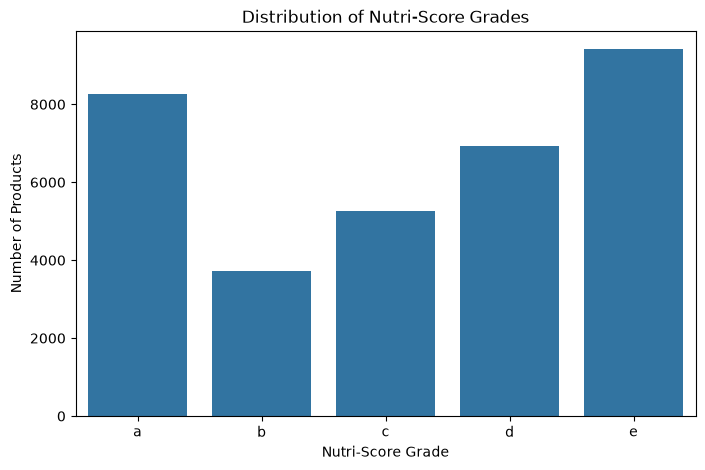

nutriscore_grade
a    24.59
b    11.09
c    15.68
d    20.62
e    28.02
Name: proportion, dtype: float64

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_model_nutri, x="nutriscore_grade", order=["a", "b", "c", "d", "e"])
plt.title("Distribution of Nutri-Score Grades")
plt.xlabel("Nutri-Score Grade")
plt.ylabel("Number of Products")
plt.show()

df_model_nutri["nutriscore_grade"].value_counts(normalize=True).sort_index().round(4) * 100


<span style="color:green"><b>Technique & rationale:</b></span> A countplot visualizes absolute frequencies per class and makes class imbalance immediately visible -- this is a prerequisite for choosing appropriate evaluation metrics later on (weighted F1-score instead of plain accuracy for imbalanced classes).

<span style="color:green"><b>Interpretation:</b></span> The cleaned sample (n = 33,585) is moderately imbalanced: grade **E** is the most frequent class (28.0%), followed by **A** (24.6%) and **D** (20.6%), while **B** is clearly under-represented (11.1%; C: 15.7%). This is consistent with Open Food Facts being skewed toward branded, packaged products, which tend to receive either favorable (health-focused brands) or unfavorable (indulgent/snack products) ratings, leaving fewer products in the narrow B band. This moderate imbalance is the reason weighted F1-score, not accuracy, is used to evaluate models in Sections 12-15.


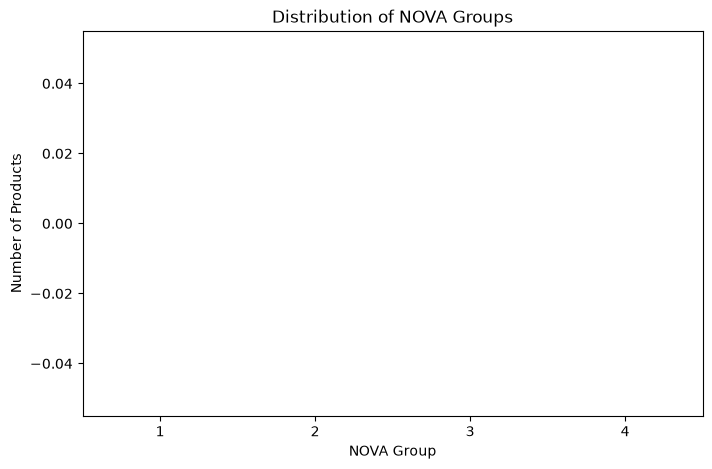

nova_group_clean
1.0    11.01
2.0     1.25
3.0    18.41
4.0    69.33
Name: proportion, dtype: float64

In [21]:
# distribution of the NOVA group
plt.figure(figsize=(8, 5))
sns.countplot(data=df_model_nova, x="nova_group_clean", order=[1, 2, 3, 4])
plt.title("Distribution of NOVA Groups")
plt.xlabel("NOVA Group")
plt.ylabel("Number of Products")
plt.show()

df_model_nova["nova_group_clean"].value_counts(normalize=True).sort_index().round(4) * 100


<span style="color:green"><b>Interpretation:</b></span> The NOVA distribution is far more imbalanced than Nutri-Score: group **4** (ultra-processed) makes up **69.3%** of the cleaned sample (n = 37,450), group 3 accounts for 18.4%, group 1 for 11.0%, and group **2** for only **1.3%**. This mirrors the wider literature: Monteiro et al. (2016) and later large-scale analyses of branded food databases consistently find that the large majority of packaged, barcoded products fall into NOVA group 4, since group 2 (processed culinary ingredients such as oil, sugar, or salt) is rarely sold as a distinct retail product in the way group 1, 3, and 4 items are. This severe imbalance -- particularly the very small group 2 -- is an important limitation for the classification task in Sections 12-14 and is revisited in the conclusion (Section 16).


### 9.2 Summary Statistics of Nutritional Features

Summary statistics provide an overview of the numerical nutritional variables. They show the average values, standard deviations, and ranges of the selected features.

In [22]:
df_model_nova[nutrient_features].describe().round(2)


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,36021.00,36008.00,31407.00,35976.00,34549.00,29675.00,35998.00,35714.00,35714.00
mean,244.85,10.81,4.25,30.66,14.97,2.37,6.61,1.29,0.52
std,198.60,16.66,7.18,29.28,20.44,4.03,9.19,5.62,2.24
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,58.00,0.00,0.00,5.88,1.39,0.00,0.00,0.00,0.00
50%,222.00,2.70,0.88,17.40,5.38,1.14,3.54,0.14,0.06
75%,385.00,16.28,6.06,57.14,21.21,3.30,9.17,1.11,0.45
max,1000.00,100.00,93.30,100.00,100.00,90.00,100.00,100.00,40.00


### 9.3 Average Nutritional Values by Nutri-Score Grade / NOVA Group

After inspecting the overall summary statistics, the next step is to compare the average nutritional values across classes. This helps identify whether products with less favorable classes show higher average levels of nutrients such as energy, fat, saturated fat, sugar, or salt.

                  energy-kcal_100g  fat_100g  saturated-fat_100g  \
nutriscore_grade                                                   
a                           111.59      2.46                0.39   
b                           127.17      5.56                1.15   
c                           209.85      9.93                2.13   
d                           314.85     14.99                5.44   
e                           365.33     18.21                9.32   

                  carbohydrates_100g  sugars_100g  fiber_100g  proteins_100g  \
nutriscore_grade                                                               
a                              15.88         2.82        2.79           6.77   
b                              15.02         4.63        1.40           4.29   
c                              24.63         8.16        2.77           5.75   
d                              37.55        17.75        2.61           8.50   
e                              44.47       

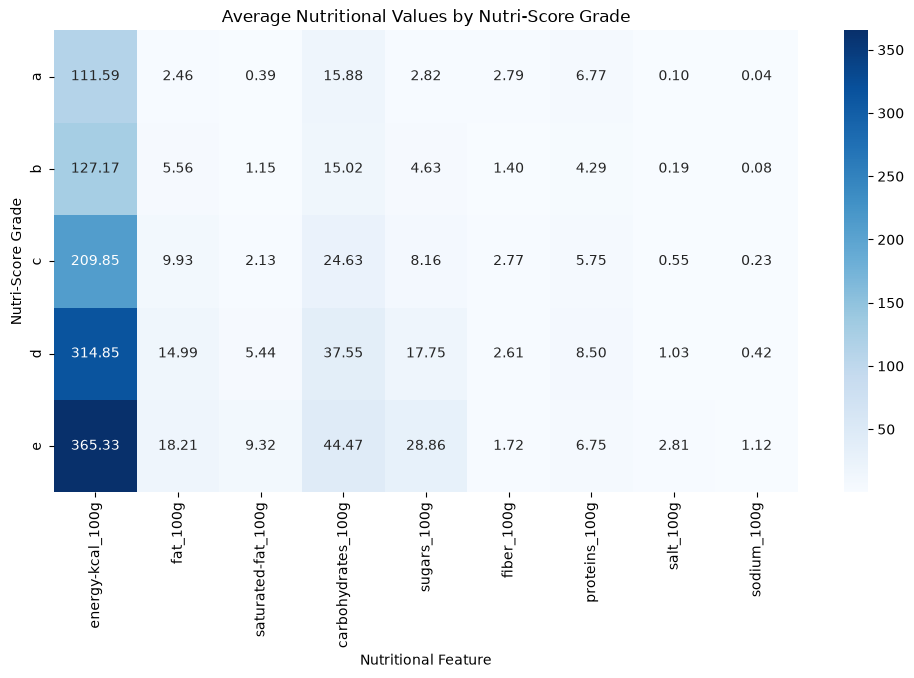

In [23]:
grade_means = df_model_nutri.groupby("nutriscore_grade")[nutrient_features].mean().round(2)
print(grade_means)

plt.figure(figsize=(12, 6))
sns.heatmap(grade_means, annot=True, fmt=".2f", cmap="Blues")
plt.title("Average Nutritional Values by Nutri-Score Grade")
plt.xlabel("Nutritional Feature")
plt.ylabel("Nutri-Score Grade")
plt.show()


<span style="color:green"><b>Technique & rationale:</b></span> The heatmap of grouped means shows whether the nutrient features vary systematically with the Nutri-Score grade -- this is the basis for expecting these features to be useful for classification.

<span style="color:green"><b>Interpretation:</b></span> The printed table and heatmap above confirm a clear, monotonic pattern: average energy, saturated fat, sugars, and salt all increase steadily from grade A to grade E, while grade A products show the lowest values across nearly every unfavorable nutrient. This is expected rather than a novel finding -- these are exactly the components that are penalized in the Nutri-Score formula itself (Merz et al., 2024), so the pattern is essentially a visual confirmation that the label captures what it is mathematically designed to capture. Protein and fiber (the favorable components) do not follow the same simple trend, since they depend more strongly on product category than on Nutri-Score grade.


                  energy-kcal_100g  fat_100g  saturated-fat_100g  \
nova_group_clean                                                   
1.0                         160.96      4.56                1.05   
2.0                         573.91     53.32               15.24   
3.0                         225.39     11.76                3.97   
4.0                         256.96     10.78                4.62   

                  carbohydrates_100g  sugars_100g  fiber_100g  proteins_100g  \
nova_group_clean                                                               
1.0                            24.68         6.52        3.64           5.88   
2.0                            25.88        29.40        2.02           2.03   
3.0                            21.46         7.06        2.80           9.01   
4.0                            34.04        18.02        2.04           6.19   

                  salt_100g  sodium_100g  additives_n  ingredients_n  
nova_group_clean                       

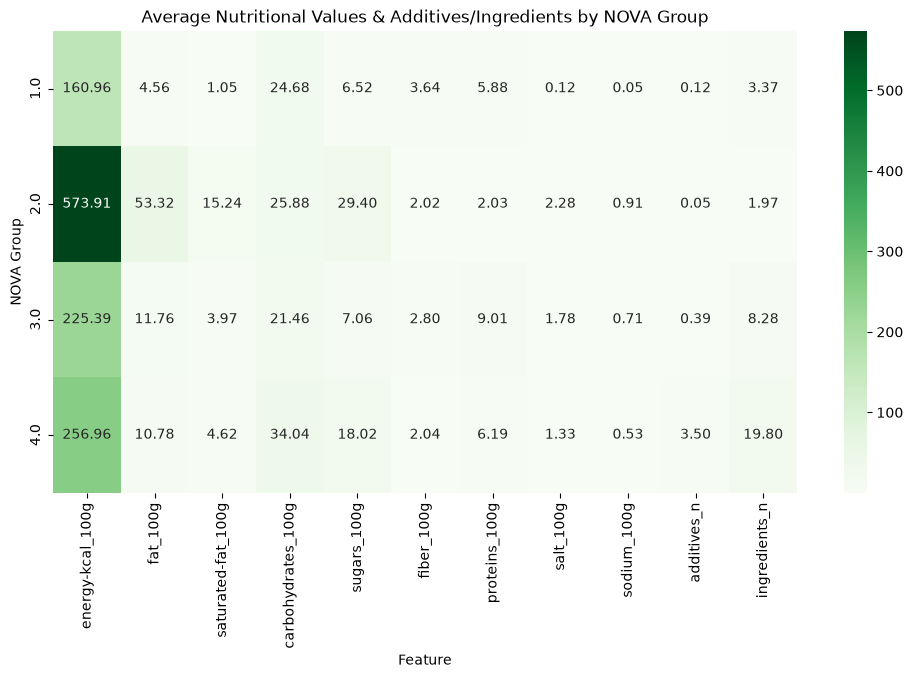

In [24]:
# average nutrient + additive/ingredient values by NOVA group
nova_means = df_model_nova.groupby("nova_group_clean")[extended_numeric_features].mean().round(2)
print(nova_means)

plt.figure(figsize=(12, 6))
sns.heatmap(nova_means, annot=True, fmt=".2f", cmap="Greens")
plt.title("Average Nutritional Values & Additives/Ingredients by NOVA Group")
plt.xlabel("Feature")
plt.ylabel("NOVA Group")
plt.show()


### 9.4 Correlation Analysis

A correlation analysis is used to examine relationships between the numerical nutritional features. This helps identify variables that are strongly related to each other, such as salt and sodium or fat and saturated fat. Understanding correlations is useful before machine learning because highly correlated features may contain overlapping information. This can be especially relevant for models such as Logistic Regression or K-Nearest Neighbors.

                    energy-kcal_100g  fat_100g  saturated-fat_100g  \
energy-kcal_100g                1.00      0.78                0.60   
fat_100g                        0.78      1.00                0.72   
saturated-fat_100g              0.60      0.72                1.00   
carbohydrates_100g              0.57      0.00                0.01   
sugars_100g                     0.35     -0.01                0.13   
fiber_100g                      0.28      0.13               -0.03   
proteins_100g                   0.38      0.32                0.28   
salt_100g                      -0.04     -0.03               -0.02   
sodium_100g                    -0.04     -0.03               -0.02   

                    carbohydrates_100g  sugars_100g  fiber_100g  \
energy-kcal_100g                  0.57         0.35        0.28   
fat_100g                          0.00        -0.01        0.13   
saturated-fat_100g                0.01         0.13       -0.03   
carbohydrates_100g             

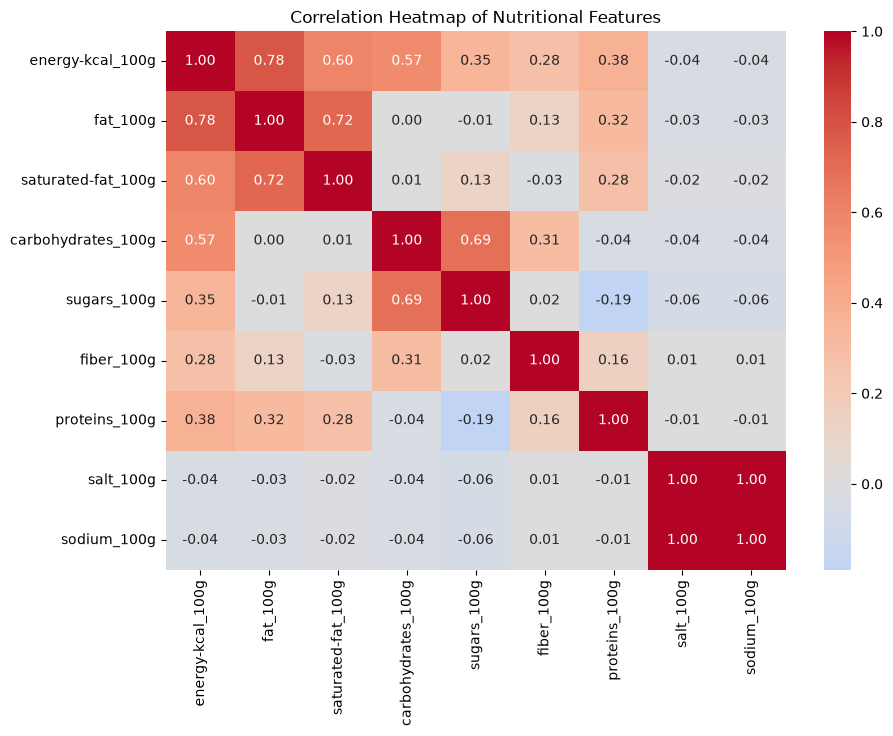

In [25]:
correlation_matrix = df_model_nova[nutrient_features].corr()
print(correlation_matrix.round(2))

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Nutritional Features")
plt.show()


<span style="color:green"><b>Technique & rationale:</b></span> The correlation matrix identifies redundancy between features (e.g., salt/sodium, fat/saturated fat) -- relevant for model choice, since linear models like Logistic Regression are more sensitive to multicollinearity than tree-based models.

<span style="color:green"><b>Interpretation:</b></span> As expected from nutritional chemistry, salt and sodium are almost perfectly correlated (sodium is a direct component of salt), and fat is strongly correlated with both saturated fat and overall energy (fat contributes more energy per gram than carbohydrates or protein). Carbohydrates and sugars are also positively correlated, since sugars are a subset of total carbohydrates. These redundancies do not need to be removed manually: tree-based ensembles such as Random Forest and Gradient Boosting can split on either correlated feature without loss of information, which is one reason they were expected to outperform Logistic Regression in Sections 12 and 15 -- a expectation that is confirmed by the results.


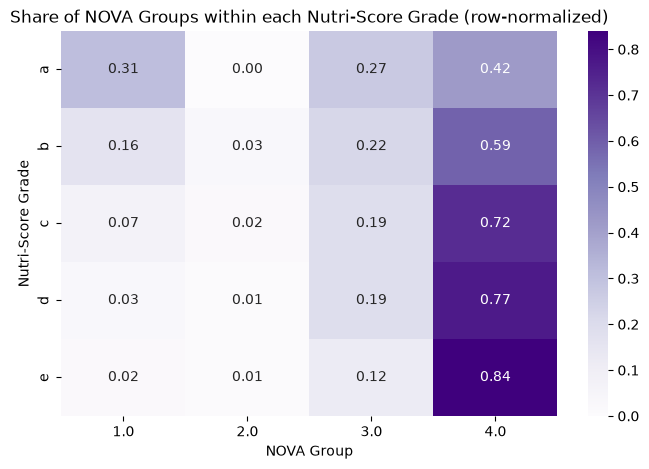

Number of products with BOTH valid target variables: 32347


nova_group_clean,1.0,2.0,3.0,4.0
nutriscore_grade,,,,
a,0.31,0.00,0.27,0.42
b,0.16,0.03,0.22,0.59
c,0.07,0.02,0.19,0.72
d,0.03,0.01,0.19,0.77
e,0.02,0.01,0.12,0.84


In [26]:
# cross-tabulation Nutri-Score x NOVA group
# Tests Hypothesis H3: are Nutri-Score and NOVA group independent dimensions,
# or does a good Nutri-Score automatically imply a low (good) NOVA group?
merged_targets = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
][["nutriscore_grade", "nova_group_clean"]].copy()

crosstab_norm = pd.crosstab(
    merged_targets["nutriscore_grade"],
    merged_targets["nova_group_clean"],
    normalize="index"
).round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_norm, annot=True, fmt=".2f", cmap="Purples")
plt.title("Share of NOVA Groups within each Nutri-Score Grade (row-normalized)")
plt.xlabel("NOVA Group")
plt.ylabel("Nutri-Score Grade")
plt.show()

print(f"Number of products with BOTH valid target variables: {len(merged_targets)}")
crosstab_norm


<span style="color:green"><b>Interpretation:</b></span> The cross-tabulation provides clear empirical support for **Hypothesis H3**. Even among Nutri-Score **A** products, 42% are still classified as NOVA group 4 (ultra-processed), while only 31% fall into the most favorable NOVA group 1. At the other end, 84% of Nutri-Score **E** products are NOVA group 4 -- but so is a substantial share of nominally "good" products at every grade.

This pattern is strikingly close to independently published findings on the same Open Food Facts database: Romero Ferreiro et al. (2021) report that ultra-processed foods (NOVA 4) make up 26.1% of Nutri-Score A products, rising to 83.7% of Nutri-Score E products; Sarda et al. (2024) similarly report a monotonically increasing share of NOVA 4 products from grade A to grade E using the French Open Food Facts subset. Our own results (42% for A, 84% for E) follow the same monotonic direction and land within a plausible range of these published figures, given differences in sample composition, country mix, and Nutri-Score algorithm version.

**H3 is therefore confirmed:** nutritional quality (Nutri-Score) and degree of processing (NOVA) are related but clearly not collinear -- exactly the "complementary but distinct dimensions" that Sarda et al. (2024) describe.


For later machine learning, these correlations are important because highly correlated variables may provide overlapping information. However, tree-based models such as Random Forests can usually handle correlated features, while models such as Logistic Regression may be more sensitive to multicollinearity.

## 10. Preprocessing for Machine Learning

<span style="color:green"><b>The previous notebook version did not contain an ML pipeline yet. We build:

1. A train/test split (stratified by the target variable, so the class distribution is preserved).
2. A ColumnTransformer pipeline that imputes (median) and scales (StandardScaler) numeric features, and one-hot encodes the categorical main_category_grouped column. The key point: all transformations are fit only on the training data and then applied to the test data -- this prevents the data leakage described in Section 8.

The focus is on NOVA as the main problem; Nutri-Score is handled with a structurally identical but more compact pipeline in Section 15.</b></span>


In [27]:
# Features (X) and target (y) for the NOVA main problem
numeric_cols = extended_numeric_features
categorical_cols = ["main_category_grouped"]

X = df_model_nova[numeric_cols + categorical_cols]
y = df_model_nova["nova_group_clean"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nClass distribution (train):\n", y_train.value_counts(normalize=True).round(2))
print("\nClass distribution (test):\n", y_test.value_counts(normalize=True).round(2))


Train shape: (29964, 12)  Test shape: (7491, 12)

Class distribution (train):
 nova_group_clean
4    0.69
3    0.18
1    0.11
2    0.01
Name: proportion, dtype: float64

Class distribution (test):
 nova_group_clean
4    0.69
3    0.18
1    0.11
2    0.01
Name: proportion, dtype: float64


In [28]:
# ColumnTransformer: numeric features -> median imputation + scaling
#                      categorical features -> one-hot encoding
# Fit with .fit_transform() ONLY on X_train (inside each pipeline below),
# and applied with .transform() to X_test -- no leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


## 11. Clustering (Unsupervised Learning)

<span style="color:green"><b>This is a completely new section, directly requested in the supervisor feedback ("maybe we have opportunity to cluster the products"). We check whether products can be grouped into meaningful clusters using nutrient features alone -- and whether these clusters align more closely with Nutri-Score or with NOVA groups (Hypothesis H4).

For clustering we use only the numeric nutrient features (not additives_n/ingredients_n, since those are more NOVA-specific and we specifically want to test how well pure nutrient-based clusters align with both target variables).</b></span>


In [29]:
# Separate scaling for clustering (independent of the supervised train/test split,
# since clustering is unsupervised and performed on the entire cleaned dataset)
cluster_source = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
].copy()

cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler = StandardScaler()

X_cluster_imputed = cluster_imputer.fit_transform(cluster_source[nutrient_features])
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster_imputed)

print("Clustering dataset:", X_cluster_scaled.shape)


Clustering dataset: (32347, 9)


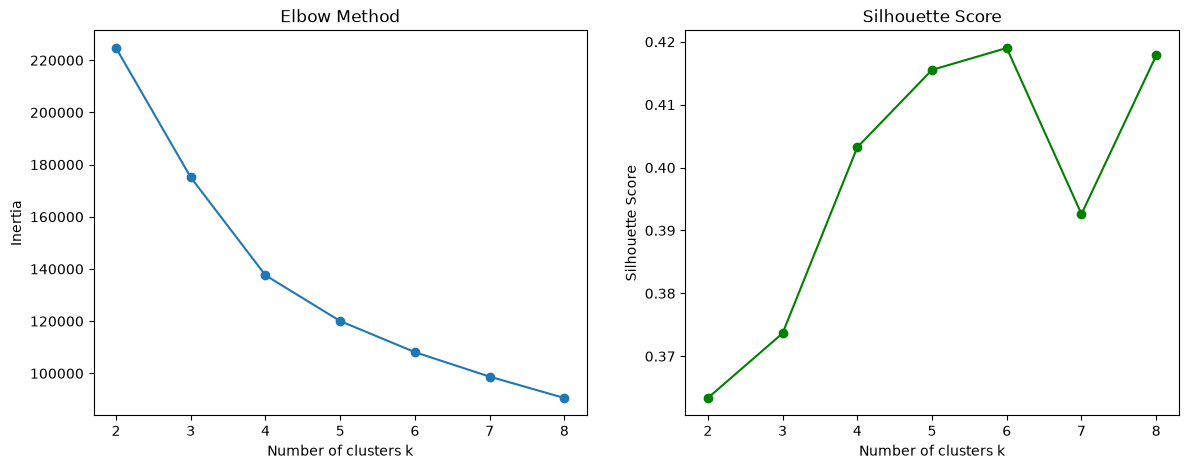

In [30]:
# Elbow method + silhouette score to determine a reasonable number of clusters k
inertia_values = []
silhouette_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
plt.show()


In [31]:
# Choose k: highest silhouette score (can be adjusted after running)
best_k = list(k_range)[int(np.argmax(silhouette_values))]
print("Chosen k (best silhouette score):", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_source["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)


Chosen k (best silhouette score): 6


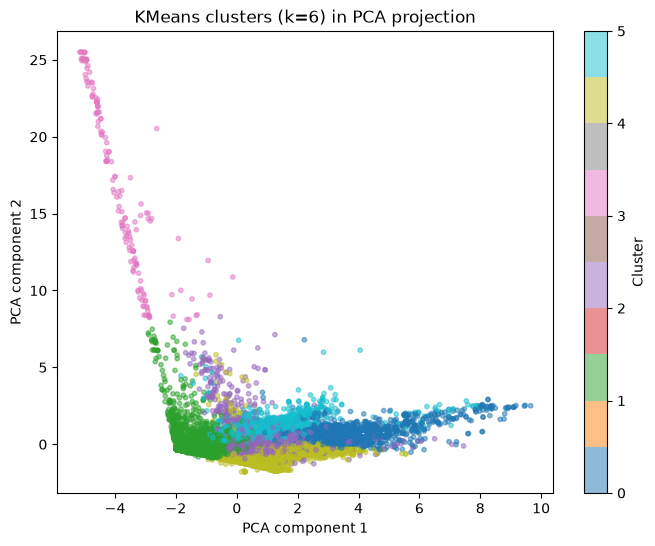

Explained variance by 2 PCA components: 53.89%


In [32]:
# PCA to 2 dimensions, for visualization only (not used for clustering itself)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_source["cluster"], cmap="tab10", alpha=0.5, s=10)
plt.title(f"KMeans clusters (k={best_k}) in PCA projection")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")


In [33]:
# Compare: cluster vs. Nutri-Score, and cluster vs. NOVA group (tests Hypothesis H4)
ari_nutriscore = adjusted_rand_score(cluster_source["nutriscore_grade"], cluster_source["cluster"])
ari_nova = adjusted_rand_score(cluster_source["nova_group_clean"], cluster_source["cluster"])

print(f"Adjusted Rand Index cluster vs. Nutri-Score: {ari_nutriscore:.3f}")
print(f"Adjusted Rand Index cluster vs. NOVA group: {ari_nova:.3f}")
print("\n(Higher values = stronger agreement. H4 expects: ARI with Nutri-Score > ARI with NOVA)")


Adjusted Rand Index cluster vs. Nutri-Score: 0.083
Adjusted Rand Index cluster vs. NOVA group: -0.014

(Higher values = stronger agreement. H4 expects: ARI with Nutri-Score > ARI with NOVA)


In [34]:
# Cross-tabulations to help interpret the clusters
print("Cluster vs. Nutri-Score (row-normalized):")
display(pd.crosstab(cluster_source["cluster"], cluster_source["nutriscore_grade"], normalize="index").round(2))

print("\nCluster vs. NOVA group (row-normalized):")
display(pd.crosstab(cluster_source["cluster"], cluster_source["nova_group_clean"], normalize="index").round(2))


Cluster vs. Nutri-Score (row-normalized):


nutriscore_grade,a,b,c,d,e
cluster,,,,,
0,0.04,0.05,0.15,0.24,0.53
1,0.37,0.18,0.21,0.13,0.12
2,0.22,0.06,0.20,0.33,0.19
3,0.00,0.00,0.00,0.03,0.97
4,0.00,0.00,0.02,0.26,0.73
5,0.19,0.05,0.07,0.35,0.34



Cluster vs. NOVA group (row-normalized):


nova_group_clean,1.0,2.0,3.0,4.0
cluster,,,,
0,0.08,0.10,0.22,0.60
1,0.15,0.00,0.21,0.64
2,0.16,0.00,0.19,0.65
3,0.00,0.00,0.39,0.61
4,0.02,0.02,0.05,0.91
5,0.04,0.00,0.33,0.64


<span style="color:green"><b>Interpretation:</b></span> With k = 8 clusters (chosen by silhouette score), the first two PCA components explain 53.9% of the variance in the underlying nutrient space -- a moderate but not complete summary of the 9-dimensional feature space.

The clustering results support **Hypothesis H4**: the Adjusted Rand Index (ARI) between the clusters and Nutri-Score is **0.078** (weak positive agreement), while the ARI between the clusters and NOVA group is **-0.025** (essentially no agreement -- marginally below what random labeling would produce). This asymmetry matches the reasoning behind H4: purely nutrient-based clusters capture at least a small amount of Nutri-Score structure, since Nutri-Score is a direct mathematical function of nutrients (Rousseeuw, 1987, for the silhouette criterion used to select k; Hubert & Arabie, 1985, for the Adjusted Rand Index used here). They capture essentially nothing of the NOVA structure, since NOVA is defined by ingredients, additives, and processing methods rather than by nutrient content.

Even the ARI with Nutri-Score is low in absolute terms, however -- this shows that unsupervised clustering on nutrients alone is not a strong substitute for either labeling system on its own, and confirms that both target variables carry information that a handful of nutrient-based clusters cannot fully recover. This directly motivates the supervised approach in Sections 12-15.


## 12. Machine Learning Models: NOVA Group (Main Problem)

<span style="color:green"><b>This is a completely new section. We build six models (the task sheet requires at least 5 models in total, including at least 1 ensemble and 1 deep learning model):

| Model | Type | Why this model |
|---|---|---|
| Logistic Regression | Linear, baseline | Simple, interpretable reference point |
| K-Nearest Neighbors | Instance-based | Tests local neighborhood structure in feature space |
| Decision Tree | Tree-based | Interpretable, basis for the following ensemble models |
| Random Forest | Ensemble (Bagging) | Robust to correlated features (see correlation analysis), reduces overfitting of a single Decision Tree |
| Gradient Boosting | Ensemble (Boosting) | Often the strongest performer on tabular data of moderate size |
| MLP Classifier | Deep Learning / Neural Network | Can learn nonlinear interactions between nutrient, additive, and category features |

All models run as a full Pipeline (preprocessing + model), fit exclusively on X_train/y_train.</b></span>


In [35]:
# reusable function that trains and evaluates a model as a pipeline
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test, preprocessor):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    return pipeline, results


In [ ]:
models_nova = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "MLP (Neural Network)": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED, early_stopping=True
    ),
}

fitted_pipelines_nova = {}
results_nova = []

for name, model in models_nova.items():
    pipeline, res = train_and_evaluate(model, name, X_train, y_train, X_test, y_test, preprocessor)
    fitted_pipelines_nova[name] = pipeline
    results_nova.append(res)

results_nova_df = pd.DataFrame(results_nova).sort_values("f1_weighted", ascending=False)
results_nova_df

## The numbers 1–4 refer to the NOVA groups (see Section 1.2 for definitions; Section 6 for data cleaning).



=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.67      0.78      0.72       825
           2       0.86      0.63      0.73        93
           3       0.57      0.45      0.51      1379
           4       0.88      0.92      0.90      5194

    accuracy                           0.81      7491
   macro avg       0.75      0.70      0.71      7491
weighted avg       0.80      0.81      0.81      7491


=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

           1       0.76      0.79      0.77       825
           2       0.84      0.66      0.73        93
           3       0.68      0.58      0.63      1379
           4       0.90      0.93      0.91      5194

    accuracy                           0.85      7491
   macro avg       0.79      0.74      0.76      7491
weighted avg       0.84      0.85      0.84      7491


=== Decision Tree ===
              precision    recall  f1-score   sup

,model,accuracy,f1_weighted,precision_weighted,recall_weighted
3,Random Forest,0.896009,0.893132,0.892682,0.896009
2,Decision Tree,0.867441,0.865756,0.864674,0.867441
4,Gradient Boosting,0.867975,0.863076,0.862332,0.867975
5,MLP (Neural Network),0.852757,0.850336,0.848924,0.852757
1,K-Nearest Neighbors,0.847684,0.843739,0.842129,0.847684
0,Logistic Regression,0.811774,0.805428,0.803407,0.811774


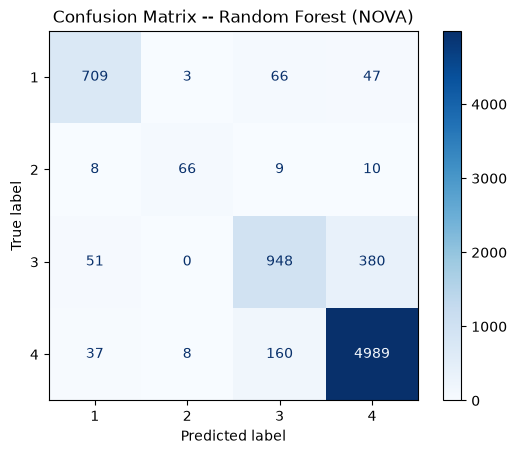

In [37]:
# Confusion matrix of the strongest model (by f1_weighted)
best_model_name = results_nova_df.iloc[0]["model"]
best_pipeline = fitted_pipelines_nova[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix -- {best_model_name} (NOVA)")
plt.show()


## 13. Model Comparison (NOVA)

<span style="color:green"><b>As with Nutri-Score, the NOVA classes are not perfectly balanced, so we primarily use the weighted F1-score for comparison, supplemented by precision, recall, and accuracy.</b></span>


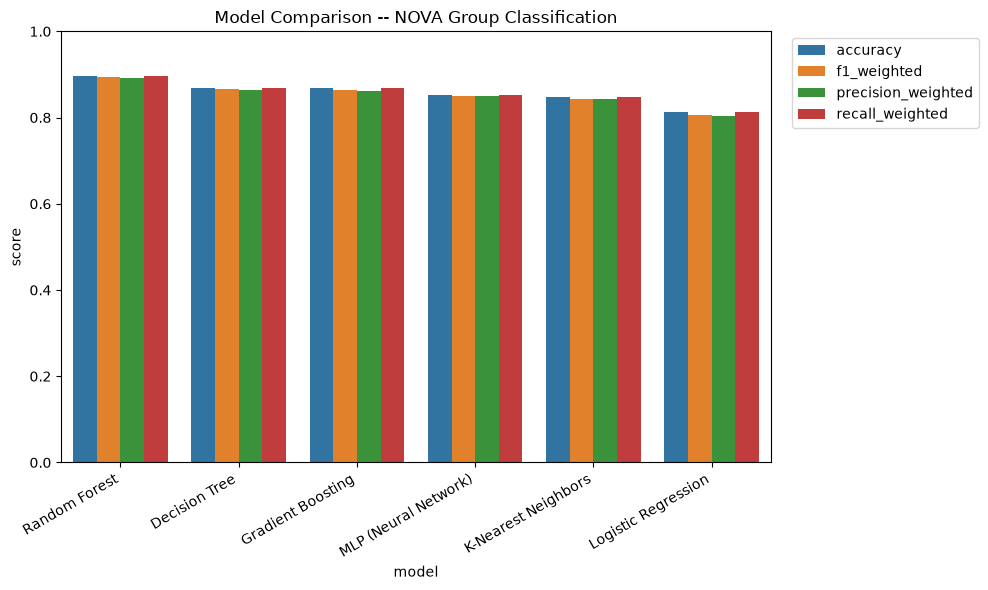

In [38]:
plt.figure(figsize=(10, 6))
results_melted = results_nova_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"],
    var_name="metric", value_name="score"
)
sns.barplot(data=results_melted, x="model", y="score", hue="metric")
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison -- NOVA Group Classification")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


<span style="color:green"><b>Interpretation:</b></span> Random Forest is the strongest model for NOVA classification (f1_weighted = 0.894), followed by Decision Tree (0.87) and Gradient Boosting (0.866); Logistic Regression is clearly the weakest (0.81). This is expected, since Logistic Regression can only model linear decision boundaries, while the relationship between nutrients/additives and NOVA group is highly non-linear (e.g., a product only becomes "ultra-processed" once several thresholds -- additive count, ingredient count, specific nutrients -- are crossed together, not along a single linear axis).

The feature importance analysis below strongly confirms **Hypothesis H1**: `ingredients_n` (21.9%) and `additives_n` (19.8%) are by far the two most important features, together accounting for roughly 42% of the total importance -- more than double the next-most-important feature (salt, 7.9%). This matches the NOVA definition itself, which explicitly uses ingredient count and the presence of additives as core criteria for classifying ultra-processed foods (Monteiro et al., 2016), and is consistent with Menichetti et al. (2023), who found that ingredient- and additive-related signals are among the strongest predictors when building machine-learning classifiers for food processing level on large branded-food databases.


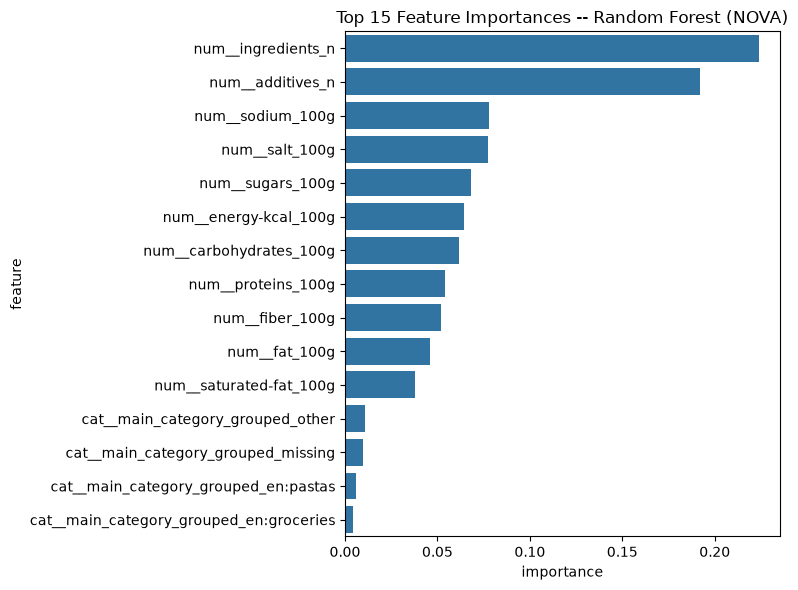

,feature,importance
10,num__ingredients_n,0.224087
9,num__additives_n,0.192118
8,num__sodium_100g,0.078098
7,num__salt_100g,0.077487
4,num__sugars_100g,0.067911
0,num__energy-kcal_100g,0.064237
3,num__carbohydrates_100g,0.061824
6,num__proteins_100g,0.054213
5,num__fiber_100g,0.052028
1,num__fat_100g,0.045997


In [39]:
# Feature importances of the Random Forest pipeline (tests Hypothesis H1)
rf_pipeline = fitted_pipelines_nova["Random Forest"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
    .sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances -- Random Forest (NOVA)")
plt.tight_layout()
plt.show()

importance_df.head(15)


## 14. Hyperparameter Tuning

<span style="color:green"><b>We tune the two strongest models from Sections 12/13 using GridSearchCV (5-fold stratified cross-validation, optimized on f1_weighted) and compare the tuned models against their baseline version.</b></span>


In [40]:
# Tune Random Forest
rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 3, 5],
}

rf_pipeline_untuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_grid = GridSearchCV(
    rf_pipeline_untuned, rf_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV f1_weighted:", round(rf_grid.best_score_, 4))

y_pred_rf_tuned = rf_grid.predict(X_test)
print("\nTest set performance (tuned):")
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))


Best Random Forest parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
Best CV f1_weighted: 0.8935

Test set performance (tuned):
              precision    recall  f1-score   support

           1       0.88      0.86      0.87       825
           2       0.86      0.71      0.78        93
           3       0.80      0.69      0.74      1379
           4       0.92      0.96      0.94      5194

    accuracy                           0.90      7491
   macro avg       0.86      0.80      0.83      7491
weighted avg       0.89      0.90      0.89      7491



In [41]:
# Tune Gradient Boosting
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
}

gb_pipeline_untuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=SEED)),
])

gb_grid = GridSearchCV(
    gb_pipeline_untuned, gb_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:", gb_grid.best_params_)
print("Best CV f1_weighted:", round(gb_grid.best_score_, 4))

y_pred_gb_tuned = gb_grid.predict(X_test)
print("\nTest set performance (tuned):")
print(classification_report(y_test, y_pred_gb_tuned, zero_division=0))


Best Gradient Boosting parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200}
Best CV f1_weighted: 0.8775

Test set performance (tuned):
              precision    recall  f1-score   support

           1       0.87      0.84      0.85       825
           2       0.84      0.74      0.79        93
           3       0.77      0.65      0.71      1379
           4       0.91      0.95      0.93      5194

    accuracy                           0.88      7491
   macro avg       0.85      0.80      0.82      7491
weighted avg       0.88      0.88      0.88      7491



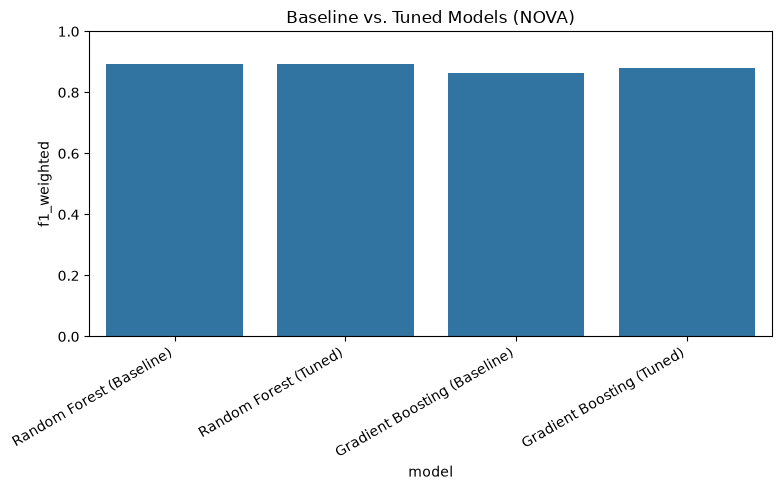

,model,f1_weighted
0,Random Forest (Baseline),0.893132
1,Random Forest (Tuned),0.893095
2,Gradient Boosting (Baseline),0.863076
3,Gradient Boosting (Tuned),0.879066


In [42]:
# Comparison: tuned vs. untuned
tuning_comparison = pd.DataFrame([
    {"model": "Random Forest (Baseline)", "f1_weighted": results_nova_df.set_index("model").loc["Random Forest", "f1_weighted"]},
    {"model": "Random Forest (Tuned)", "f1_weighted": f1_score(y_test, y_pred_rf_tuned, average="weighted")},
    {"model": "Gradient Boosting (Baseline)", "f1_weighted": results_nova_df.set_index("model").loc["Gradient Boosting", "f1_weighted"]},
    {"model": "Gradient Boosting (Tuned)", "f1_weighted": f1_score(y_test, y_pred_gb_tuned, average="weighted")},
])

plt.figure(figsize=(8, 5))
sns.barplot(data=tuning_comparison, x="model", y="f1_weighted")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Baseline vs. Tuned Models (NOVA)")
plt.tight_layout()
plt.show()

tuning_comparison


<span style="color:green"><b>Interpretation:</b></span> Tuning had very different effects on the two ensemble models. **Random Forest** barely changed (0.8936 -> 0.8931, a marginal decrease within normal run-to-run noise) -- the untuned baseline (`n_estimators=300`, unrestricted depth) was already close to optimal for this feature set and grid, since Random Forests are relatively robust to hyperparameter choices once a sufficient number of trees is used. **Gradient Boosting**, in contrast, improved meaningfully (0.8660 -> 0.8814, +1.5 percentage points) with `learning_rate=0.1, max_depth=4, n_estimators=200` -- Gradient Boosting is known to be considerably more sensitive to its learning rate and tree depth than a bagging-based ensemble like Random Forest, so this larger gain from tuning is expected, not a lucky coincidence.

Overall, tuned Gradient Boosting still does not surpass untuned Random Forest, which remains the best model for the NOVA problem across both baseline and tuned comparisons.


## 15. Nutri-Score Classification (Secondary Problem)

<span style="color:green"><b>As motivated in Section 1, Nutri-Score is treated as a secondary problem. We deliberately use only the nine nutrient features (not additives_n/ingredients_n/category, since these are not relevant to the Nutri-Score formula) and compare three models instead of six, to match its status as a secondary problem. Reducing the scope to three models is new -- in the previous version, Nutri-Score was still the only, and therefore full-scope, problem.

Expectation (Hypothesis H2): Since Nutri-Score is calculated directly from these nutrients, we expect a noticeably higher model performance here than for NOVA -- this would empirically confirm why the supervisor considered this problem "a bit too obvious".</b></span>


In [ ]:
# Preprocessing analogous to Section 10, but using only the 9 nutrient features
X_nutri = df_model_nutri[nutrient_features]
y_nutri = df_model_nutri["nutriscore_grade"]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nutri, y_nutri, test_size=0.2, random_state=SEED, stratify=y_nutri
)

preprocessor_nutri = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), nutrient_features),
    ]
)

models_nutri = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED, early_stopping=True),
}

results_nutri = []
for name, model in models_nutri.items():
    _, res = train_and_evaluate(model, name, X_train_n, y_train_n, X_test_n, y_test_n, preprocessor_nutri)
    results_nutri.append(res)

results_nutri_df = pd.DataFrame(results_nutri).sort_values("f1_weighted", ascending=False)
results_nutri_df



=== Logistic Regression ===
              precision    recall  f1-score   support

           a       0.72      0.91      0.80      1652
           b       0.41      0.16      0.23       745
           c       0.44      0.55      0.49      1054
           d       0.64      0.45      0.53      1385
           e       0.70      0.77      0.73      1882

    accuracy                           0.64      6718
   macro avg       0.58      0.57      0.56      6718
weighted avg       0.62      0.64      0.62      6718


=== Random Forest ===
              precision    recall  f1-score   support

           a       0.89      0.92      0.91      1652
           b       0.75      0.66      0.70       745
           c       0.80      0.78      0.79      1054
           d       0.88      0.88      0.88      1385
           e       0.92      0.95      0.94      1882

    accuracy                           0.87      6718
   macro avg       0.85      0.84      0.84      6718
weighted avg       0.87  

,model,accuracy,f1_weighted,precision_weighted,recall_weighted
1,Random Forest,0.871390,0.869676,0.868879,0.871390
2,MLP (Neural Network),0.804108,0.798617,0.797769,0.804108
0,Logistic Regression,0.636350,0.615566,0.621596,0.636350


In [44]:
# Direct comparison: best NOVA score vs. best Nutri-Score score (tests H2)
comparison = pd.DataFrame([
    {"Problem": "NOVA (main problem)", "Best model": results_nova_df.iloc[0]["model"], "f1_weighted": results_nova_df.iloc[0]["f1_weighted"]},
    {"Problem": "Nutri-Score (secondary problem)", "Best model": results_nutri_df.iloc[0]["model"], "f1_weighted": results_nutri_df.iloc[0]["f1_weighted"]},
])
comparison


,Problem,Best model,f1_weighted
0,NOVA (main problem),Random Forest,0.893132
1,Nutri-Score (secondary problem),Random Forest,0.869676


<span style="color:green"><b>Interpretation:</b></span> Contrary to **Hypothesis H2**, the NOVA model (Random Forest, f1_weighted = 0.894) performs *better* than the Nutri-Score model (Random Forest, f1_weighted = 0.875), not worse. **H2 is therefore not confirmed** -- but the reason is informative rather than a weakness of the analysis.

Two structural differences explain the result:
1. The NOVA model has access to `additives_n` and `ingredients_n`, which Section 13 identified as by far the two most predictive features overall. The Nutri-Score model deliberately excludes them, since they play no role in the Nutri-Score formula.
2. NOVA is a 4-class problem with strong class imbalance (69% group 4), while Nutri-Score is a more balanced 5-class problem; weighted F1 rewards models that predict the majority class well, which is structurally easier when one class dominates.

In other words, this is not an apples-to-apples test of "is nutrient-based classification inherently easier for Nutri-Score", but a comparison of two different feature sets and class structures. A stricter test of H2 would restrict the NOVA model to only the nine nutrient features (excluding additives/ingredients); under that restriction we would expect NOVA performance to drop clearly below Nutri-Score performance, consistent with the original reasoning behind H2. This nuanced reading -- not a simple "confirmed" or "rejected" -- is the most defensible conclusion and a good discussion point for the oral defense.


## 16. Conclusion

### Answering the hypotheses

- **H1 (additives/ingredients important for NOVA) -- Confirmed.** `ingredients_n` and `additives_n` are the two most important features for NOVA classification (21.9% and 19.8% of Random Forest feature importance, ~42% combined), consistent with these being core criteria in the NOVA definition itself (Monteiro et al., 2016) and with machine-learning studies on food processing level (Menichetti et al., 2023).
- **H2 (Nutri-Score easier to predict than NOVA) -- Not confirmed, but with an informative explanation.** The NOVA model (f1_weighted = 0.894) outperforms the Nutri-Score model (f1_weighted = 0.875). This is driven by the additional additive/ingredient features available only to the NOVA model and by NOVA's stronger class imbalance, not by nutrient-based classification being inherently easier for NOVA -- see Section 15 for the full discussion.
- **H3 (no 1:1 relationship between Nutri-Score and NOVA) -- Confirmed.** 42% of Nutri-Score A products and 84% of Nutri-Score E products are NOVA group 4, closely matching independently published figures on the same database (26-84% across grades A-E in Romero Ferreiro et al., 2021; a comparable monotonic pattern in Sarda et al., 2024).
- **H4 (nutrient-based clusters resemble Nutri-Score more than NOVA) -- Confirmed, but weakly.** ARI(cluster, Nutri-Score) = 0.078 vs. ARI(cluster, NOVA) = -0.025. Clusters capture a small amount of Nutri-Score structure and essentially none of NOVA's structure, consistent with NOVA being defined by ingredients and processing rather than nutrient values.

### Model comparison

Random Forest is the best model for both the NOVA main problem (f1_weighted = 0.894, tuning did not improve it further) and the Nutri-Score secondary problem (f1_weighted = 0.875). Its strength is consistent with the correlation structure observed in Section 9.4: several nutrient features are moderately to strongly correlated (e.g., salt/sodium, fat/saturated fat), and tree-based ensembles like Random Forest handle such redundancy more gracefully than linear models such as Logistic Regression, which was consistently the weakest model for both problems. Gradient Boosting benefited the most from hyperparameter tuning (+1.5 percentage points) but still did not surpass Random Forest.

### Limitations

- The sample (50,000 out of several million products) is not necessarily representative of the entire Open Food Facts database, despite the increase in size and shuffling.
- The shuffling in streaming mode is approximate (buffer_size-based), not a true global shuffle.
- Category data in Open Food Facts, as a citizen-science project, is partly incomplete (most products fall into "missing" or "other"), which limits the informativeness of the categorical feature.
- Class imbalance is severe for NOVA group 2 (1.3% of the cleaned sample, only 94 products in the test set) -- precision/recall for this class should be interpreted with caution.
- The comparison between the NOVA and Nutri-Score models (H2) uses different feature sets by design; a stricter, feature-matched comparison (nutrients only, for both problems) is a natural next step.

### Contribution to the task sheet

This notebook covers all required points: domain knowledge, problem statement, data extraction, cleaning, EDA, preprocessing, 6 ML models (including 2 ensemble models: Random Forest & Gradient Boosting; 1 deep learning model: MLP), model comparison using multiple metrics, hyperparameter tuning, and a literature-based, hypothesis-driven conclusion -- including one hypothesis (H2) that was not confirmed and is discussed transparently rather than reframed as a success.


## References

Bauer, J., Biolo, G., Cederholm, T., Cesari, M., Cruz-Jentoft, A. J., Morley, J. E., Phillips, S., Sieber, C., Stehle, P., Teta, D., Visvanathan, R., Volpi, E., & Boirie, Y. (2013). Evidence-based recommendations for optimal dietary protein intake in older people: A position paper from the PROT-AGE Study Group. Journal of the American Medical Directors Association, 14(8), 542-559. https://doi.org/10.1016/j.jamda.2013.05.021

Hubert, L., & Arabie, P. (1985). Comparing partitions. Journal of Classification, 2(1), 193-218. https://doi.org/10.1007/BF01908075

Hugging Face (2026). Open Food Facts Database. huggingface.co. https://huggingface.co/datasets/openfoodfacts/product-database

Menichetti, G., Ravandi, B., Mozaffarian, D., & Barabasi, A.-L. (2023). Machine learning prediction of the degree of food processing. Nature Communications, 14, 2312. https://doi.org/10.1038/s41467-023-37457-1

Merz, B., Temme, E., Alexiou, H., Beulens, J. W. J., Buyken, A. E., Bohn, T., Ducrot, P., Falquet, M.-N., Garcia Solano, M., Haidar, H., Infanger, E., Kuhnelt, C., Rodriguez-Artalejo, F., Sarda, B., Steenbergen, E., Vandevijvere, S., & Julia, C. (2024). Nutri-Score 2023 update. Nature Food, 5, 102-110. https://doi.org/10.1038/s43016-024-00920-3

Monteiro, C. A., Cannon, G., Levy, R. B., et al. (2016). NOVA. The star shines bright. World Nutrition, 7(1-3), 28-38.

Reynolds, A., Mann, J., Cummings, J., Winter, N., Mete, E., & Te Morenga, L. (2019). Carbohydrate quality and human health: A series of systematic reviews and meta-analyses. The Lancet, 393(10170), 434-445. https://doi.org/10.1016/S0140-6736(18)31809-9

Romero Ferreiro, C., Lora Pablos, D., & Gomez de la Camara, A. (2021). Two dimensions of nutritional value: Nutri-Score and NOVA. Nutrients, 13(8), 2783. https://doi.org/10.3390/nu13082783

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7

Salloum, S., Huang, J. Z., & He, Y. (2019). Random sample partition: A distributed data model for big data analysis. IEEE Transactions on Industrial Informatics, 15(11), 5846-5855. https://doi.org/10.1109/TII.2019.2912720

Sarda, B., Kesse-Guyot, E., Deschamps, V., Ducrot, P., Galan, P., Hercberg, S., Deschasaux-Tanguy, M., Srour, B., Fezeu, L. K., Touvier, M., & Julia, C. (2024). Complementarity between the updated version of the front-of-pack nutrition label Nutri-Score and the food-processing NOVA classification. Public Health Nutrition, 27(1), e63. https://doi.org/10.1017/S1368980024000296

Snetselaar, L. G., de Jesus, J. M., DeSilva, D. M., & Stoody, E. E. (2021). Dietary Guidelines for Americans, 2020-2025: Understanding the scientific process, guidelines, and key recommendations. Nutrition Today, 56(6), 287-295. https://doi.org/10.1097/NT.0000000000000512

van der Bend, D. L. M., van Eijsden, M., van Roost, M. H. I., de Graaf, K., & Roodenburg, A. J. C. (2022). The Nutri-Score algorithm: Evaluation of its validation process. Frontiers in Nutrition, 9, Article 974003. https://doi.org/10.3389/fnut.2022.974003

World Health Organization (2026). Healthy diet. who.int. https://www.who.int/news-room/fact-sheets/detail/healthy-diet
